In [4]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os, json

print("✅ Libraries ready! TF version:", tf.__version__)
print("✅ GPU:", tf.config.list_physical_devices('GPU'))

2026-06-11 16:11:39.947184: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781194299.969612     571 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781194299.977047     571 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781194299.997142     571 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781194299.997163     571 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781194299.997165     571 computation_placer.cc:177] computation placer alr

✅ Libraries ready! TF version: 2.19.0
✅ GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
import os

# Find the correct path
for root, dirs, files in os.walk("/kaggle/input"):
    if files:
        print(root)
        break

/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot


In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

# ✅ Correct path for this dataset
IMAGE_DIR = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    rotation_range=15
)

train_data = datagen.flow_from_directory(
    IMAGE_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset="training",
    class_mode="categorical"
)

val_data = datagen.flow_from_directory(
    IMAGE_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode="categorical"
)

print(f"✅ {train_data.samples} training images, {train_data.num_classes} classes")

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
✅ 16516 training images, 15 classes


In [7]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ✅ Auto-saves best model to Kaggle output after every epoch
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/kaggle/working/crop_disease_model.h5",
    save_best_only=True,
    monitor="val_accuracy",
    verbose=1
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[checkpoint],
    verbose=1
)

print("✅ Training complete! Model saved!")

I0000 00:00:1781194308.717714     571 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781194308.722911     571 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10


I0000 00:00:1781194315.593715     661 service.cc:152] XLA service 0x7b6fa80107b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781194315.593753     661 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781194315.593757     661 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781194316.549114     661 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-11 16:12:04.519411: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 16:12:04.656912: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1781194326.824795     661 device_co

225/517 ━━━━━━━━━━━━━━━━━━━━ 1:39 340ms/step - accuracy: 0.5010 - loss: 1.5836

2026-06-11 16:13:31.511575: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 16:13:31.650554: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


...


Epoch 2: finished saving model to /kaggle/working/crop_disease_model.h5
517/517 ━━━━━━━━━━━━━━━━━━━━ 226s 438ms/step - accuracy: 0.8435 - loss: 0.4733 - val_accuracy: 0.8872 - val_loss: 0.3500
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.8697 - loss: 0.3971
Epoch 3: val_accuracy did not improve from 0.88719
517/517 ━━━━━━━━━━━━━━━━━━━━ 220s 425ms/step - accuracy: 0.8679 - loss: 0.3961 - val_accuracy: 0.8833 - val_loss: 0.3389
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.8818 - loss: 0.3563
Epoch 4: val_accuracy improved from 0.88719 to 0.89229, saving model to /kaggle/working/crop_disease_model.h5



Epoch 4: finished saving model to /kaggle/working/crop_disease_model.h5
517/517 ━━━━━━━━━━━━━━━━━━━━ 220s 425ms/step - accuracy: 0.8802 - loss: 0.3585 - val_accuracy: 0.8923 - val_loss: 0.3084
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.8855 - loss: 0.3363
Epoch 5: val_accuracy improved from 0.89229 to 0.90660, saving model to /kaggle/working/crop_disease_model.h5



Epoch 5: finished saving model to /kaggle/working/crop_disease_model.h5
517/517 ━━━━━━━━━━━━━━━━━━━━ 220s 426ms/step - accuracy: 0.8853 - loss: 0.3366 - val_accuracy: 0.9066 - val_loss: 0.2785
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.8975 - loss: 0.2991
Epoch 6: val_accuracy improved from 0.90660 to 0.91460, saving model to /kaggle/working/crop_disease_model.h5



Epoch 6: finished saving model to /kaggle/working/crop_disease_model.h5
517/517 ━━━━━━━━━━━━━━━━━━━━ 231s 447ms/step - accuracy: 0.8977 - loss: 0.3019 - val_accuracy: 0.9146 - val_loss: 0.2496
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.8966 - loss: 0.2988
Epoch 7: val_accuracy did not improve from 0.91460
517/517 ━━━━━━━━━━━━━━━━━━━━ 224s 434ms/step - accuracy: 0.8962 - loss: 0.2957 - val_accuracy: 0.9090 - val_loss: 0.2598
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.9028 - loss: 0.2863
Epoch 8: val_accuracy did not improve from 0.91460
517/517 ━━━━━━━━━━━━━━━━━━━━ 221s 427ms/step - accuracy: 0.9026 - loss: 0.2841 - val_accuracy: 0.9088 - val_loss: 0.2654
Epoch 9/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9086 - loss: 0.2637
Epoch 9: val_accuracy did not improve from 0.91460
517/517 ━━━━━━━━━━━━━━━━━━━━ 218s 422ms/step - accuracy: 0.9086 - loss: 0.2646 - val_accuracy: 0.9139 - val_loss: 0.2500
Epoch 10/10
517/517 ━━━━━━


Epoch 10: finished saving model to /kaggle/working/crop_disease_model.h5
517/517 ━━━━━━━━━━━━━━━━━━━━ 224s 434ms/step - accuracy: 0.9118 - loss: 0.2547 - val_accuracy: 0.9192 - val_loss: 0.2336
✅ Training complete! Model saved!


In [8]:
import json
class_names = list(train_data.class_indices.keys())
with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_names, f)
print(f"✅ Saved {len(class_names)} class names!")

✅ Saved 15 class names!


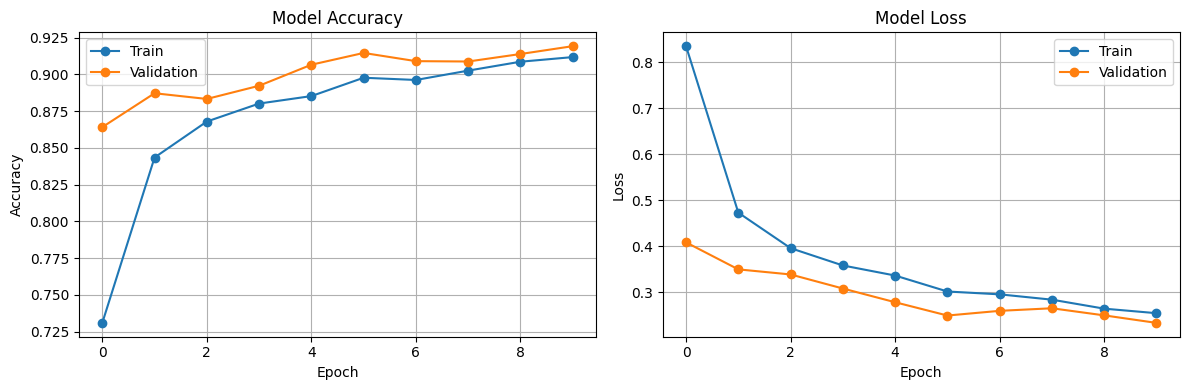

✅ Graph saved!


In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train", marker="o")
plt.plot(history.history["val_accuracy"], label="Validation", marker="o")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train", marker="o")
plt.plot(history.history["val_loss"], label="Validation", marker="o")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/training_results.png", dpi=150)
plt.show()
print("✅ Graph saved!")

In [10]:
from IPython.display import FileLink
print("Download your files from the Output panel on the right 👉")
print("Files saved:")
print("  ✅ /kaggle/working/crop_disease_model.h5")
print("  ✅ /kaggle/working/class_names.json")
print("  ✅ /kaggle/working/training_results.png")

Download your files from the Output panel on the right 👉
Files saved:
  ✅ /kaggle/working/crop_disease_model.h5
  ✅ /kaggle/working/class_names.json
  ✅ /kaggle/working/training_results.png


In [11]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [12]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import json

# Load model and class names
model = tf.keras.models.load_model("crop_disease_model.h5")
with open("class_names.json") as f:
    class_names = json.load(f)

# Treatment advice dictionary
treatments = {
    "Tomato_Late_blight": "Apply copper-based fungicide. Remove infected leaves immediately.",
    "Tomato_Early_blight": "Use chlorothalonil fungicide. Ensure proper spacing for airflow.",
    "Corn_Common_rust": "Apply fungicide early. Use rust-resistant seed varieties.",
    "Potato_Late_blight": "Remove infected plants. Apply mancozeb fungicide.",
    "Pepper__bell___Bacterial_spot": "Use copper spray. Avoid overhead watering.",
}

# UI
st.set_page_config(page_title="🌿 Crop Disease Detector", layout="centered")
st.title("🌿 AI Crop Disease Detector")
st.write("Upload a leaf photo to instantly detect disease and get treatment advice!")

uploaded_file = st.file_uploader("📸 Upload a leaf image", type=["jpg", "jpeg", "png"])

if uploaded_file:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Leaf", use_column_width=True)

    # Preprocess
    img = image.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    with st.spinner("🔍 Analyzing leaf..."):
        predictions = model.predict(img_array)
        confidence = np.max(predictions) * 100
        predicted_class = class_names[np.argmax(predictions)]

    # Clean up class name for display
    display_name = predicted_class.replace("_", " ").replace("  ", " → ")

    # Show result
    st.success(f"🔬 Detected: **{display_name}**")
    st.info(f"📊 Confidence: **{confidence:.1f}%**")

    # Show treatment
    st.subheader("💊 Recommended Treatment")
    treatment = treatments.get(predicted_class, 
                "Consult a local agricultural expert for treatment advice.")
    st.warning(treatment)

    # Healthy check
    if "healthy" in predicted_class.lower():
        st.balloons()
        st.success("🎉 Great news! Your crop appears healthy!")

2026-06-11 16:49:42.476 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 16:49:42.476 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 16:49:42.850 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-11 16:49:42.851 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 16:49:42.851 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 16:49:42.852 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 16:49:42.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [13]:
import streamlit as st
print(st.__version__)

1.58.0
